# 01 — Comprensión del problema y marco del proyecto

**Responsable:** Lucas Moncada  
**Metodología:** CRISP-DM  
**Alcance principal:** problema de negocio, objetivos, KPIs, fuente de datos, herramientas colaborativas y metodología.  
**Evidencia complementaria:** descripción del dataset, calidad preliminar y primeras distribuciones.

> En esta etapa se diagnostican los datos originales. No se eliminan registros ni se toman decisiones definitivas de limpieza.

## 1. Problema de negocio

Artistas, sellos discográficos, equipos de marketing y curadores deben priorizar canciones y recursos promocionales sin conocer completamente su desempeño futuro. El proyecto busca estudiar qué características musicales y contextuales están asociadas con la popularidad observada en Spotify.

### Pregunta central

> ¿Qué características musicales y contextuales están asociadas con la popularidad de una canción y cómo puede esta información apoyar decisiones de artistas, sellos y equipos de marketing musical?

El estudio es inicialmente **descriptivo y asociativo**. Una correlación no demuestra que modificar una característica cause mayor popularidad.

### Stakeholders y decisiones apoyadas

- **Artistas y sellos:** priorización de lanzamientos y recursos promocionales.
- **Marketing musical:** caracterización de segmentos y diseño de campañas.
- **Curadores:** comprensión de perfiles musicales y diversidad del catálogo.
- **Equipo analítico:** preparación de una base reproducible para un futuro modelo de regresión.

## 2. Objetivos

**Objetivo general:** analizar la relación entre atributos musicales y contextuales y la popularidad, preparando evidencia reproducible para una futura estimación de `popularity`.

**Objetivos específicos:**

1. Describir estructura, procedencia y calidad inicial del dataset.
2. Identificar distribuciones, anomalías y posibles sesgos de cobertura.
3. Reconocer variables potencialmente relevantes para el análisis posterior.
4. Preparar un flujo verificable para limpieza, EDA profundo y modelamiento.

## 3. KPIs e indicadores

| Tipo | Indicador | Propósito |
|---|---|---|
| Negocio | Popularidad promedio y mediana | Establecer el desempeño central del catálogo observado. |
| Negocio | Proporción con popularidad ≥ 70 | Segmento operativo de alta popularidad; el umbral deberá evaluarse mediante sensibilidad. |
| Negocio | Popularidad por género | Comparar segmentos sin interpretar diferencias como efectos causales. |
| Calidad | Completitud | Medir la disponibilidad de los datos. |
| Calidad | Duplicidad de `track_id` | Prevenir conteos sesgados y futura fuga entre entrenamiento y prueba. |
| Modelo futuro | MAE, RMSE y R² | Evaluar error y capacidad explicativa de una regresión posterior. |

## 4. Fuente de datos y herramientas colaborativas

### Fuente y limitaciones

La fuente operativa es el CSV entregado por la asignatura y preservado en `data/raw/Spotify_Tracks_Dataset.csv`. Su estructura coincide con el [Spotify Tracks Dataset de Maharshi Pandya en Kaggle](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset). Las definiciones se contrastaron con [Spotify Web API — Track](https://developer.spotify.com/documentation/web-api/reference/get-track).

Limitaciones iniciales:

- No se informa la fecha exacta de extracción.
- `popularity` es dinámica, depende de reproducciones y recencia y actualmente aparece como campo obsoleto en la API.
- No hay variables como inversión publicitaria, fecha de lanzamiento, ubicación o exposición en playlists.
- Cada género contiene exactamente 1.000 filas, señal de un muestreo balanceado que no representa necesariamente el catálogo real.
- Una pista puede estar asignada a varios géneros; una fila no equivale siempre a una canción única.

### Herramientas colaborativas y reproducibilidad

| Herramienta | Uso en el proyecto | Justificación | Estado |
|---|---|---|---|
| Git | Control de versiones local, ramas y trazabilidad por integrante | Permite revisar cambios y recuperar versiones sin sobrescribir el trabajo del equipo | En uso y conectado con `origin` |
| GitHub | Repositorio remoto privado, revisión y respaldo compartido | Centraliza la colaboración y permite integrar ramas de forma verificable | En uso: `LucasMoncadaCL/spotify-popularity-analysis` |
| Jupyter Notebook | Código, resultados e interpretación en un documento ejecutable | Facilita la revisión académica y vincula cada afirmación con su evidencia | En uso |
| Markdown | Informe técnico legible y versionable | Puede revisarse mediante Git y renderizarse sin software propietario | En uso |
| uv | Entorno y versiones reproducibles mediante `pyproject.toml` y `uv.lock` | Reduce diferencias de dependencias entre integrantes | En uso |

El flujo acordado utiliza `main` para entregas estables, `dev` para integración y ramas temporales `feature/*`, `fix/*` y `hotfix/*`. Los nombres técnicos de GitFlow se mantienen en inglés y los mensajes de commit se redactan en español.

## 5. Metodología CRISP-DM

CRISP-DM organiza el proyecto como un ciclo iterativo y no como una secuencia rígida. Su aplicación prevista es:

| Fase | Aplicación al proyecto Spotify | Estado/responsable |
|---|---|---|
| Business Understanding | Problema, stakeholders, objetivos y KPIs | Desarrollado por Lucas Moncada |
| Data Understanding | Fuente, variables, calidad inicial y distribuciones | Iniciado por Lucas Moncada |
| Data Preparation | Índice exportado, nulos, anomalías y repetición por `track_id` | Entrega al Integrante 2 |
| Modeling | Regresión base y alternativas justificadas | Etapa posterior |
| Evaluation | MAE, RMSE y R² junto con utilidad y limitaciones de negocio | Etapa posterior |
| Deployment | Entrega reproducible mediante README, notebooks, datos y presentación | Entrega académica final |

Los hallazgos posteriores pueden obligar a volver a objetivos, preparación o selección de variables; esa iteración forma parte de CRISP-DM.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from spotify_popularity.analysis.quality import column_quality_report, dataset_overview
from spotify_popularity.config import PROJECT_PATHS
from spotify_popularity.data.loader import load_raw_dataset
from spotify_popularity.data.metadata import variable_dictionary
from spotify_popularity.data.provenance import sha256_file
from spotify_popularity.visualization.distributions import (
    plot_audio_feature_distributions,
    plot_duration_distribution,
    plot_explicit_distribution,
    plot_popularity_distribution,
    save_figure,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

### Uso con criterio del ecosistema técnico

- **Pandas:** carga, tablas, selección, nulos, tipos, duplicados y agrupaciones.
- **NumPy:** conversión vectorizada de milisegundos a minutos, evitando ciclos manuales.
- **Matplotlib:** control de figuras, ejes, títulos y exportación.
- **Seaborn:** distribuciones estadísticas construidas sobre Matplotlib.
- **hashlib:** usado desde `provenance.py` para comprobar integridad mediante SHA-256. No se usa para transformar `track_id`, porque identifica canciones y no personas.

In [2]:
tracks = load_raw_dataset()
dataset_hash = sha256_file(PROJECT_PATHS.raw_dataset)
print(f"SHA-256: {dataset_hash}")
print(f"Filas: {tracks.shape[0]:,} | Columnas: {tracks.shape[1]}")

SHA-256: b202fa49909b2d5cef71a04b1d21243cfeb36414535f2ca9272aa646721177bd
Filas: 114,000 | Columnas: 21


In [3]:
tracks.iloc[:5]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 6. Descripción y diccionario de variables

El diccionario distingue variables identificadoras, contextuales, explicativas, objetivo y técnicas. La columna `Unnamed: 0` es un índice exportado y no una propiedad musical.

In [4]:
variable_dictionary()

,variable,description,conceptual_type,unit_or_range,role
0,Unnamed: 0,Índice exportado,entero,0–113999,Técnica; no predictiva
1,track_id,Identificador de la pista en Spotify,texto,ID alfanumérico,Identificador
2,artists,Nombre del artista o artistas,texto,categoría abierta,Contextual
3,album_name,Nombre del álbum,texto,categoría abierta,Contextual
4,track_name,Nombre de la canción,texto,categoría abierta,Contextual
5,popularity,Puntaje de popularidad,entero,0–100,Objetivo
6,duration_ms,Duración de la pista,entero,milisegundos,Explicativa
7,explicit,Indica contenido explícito,booleano,False/True,Explicativa
8,danceability,Aptitud percibida para bailar,decimal,0–1,Explicativa
9,energy,Intensidad y actividad percibidas,decimal,0–1,Explicativa


## 7. Inspección inicial y calidad preliminar

### 7.1 Dimensiones, tipos y duplicidad

`shape` informa el número de filas y columnas. Los tipos observados permiten contrastar la representación técnica con el significado conceptual.

In [5]:
type_report = pd.DataFrame({"dtype_observado": tracks.dtypes.astype(str)})
type_report["valores_unicos"] = tracks.nunique(dropna=False)
type_report

,dtype_observado,valores_unicos
Unnamed: 0,int64,114000
track_id,object,89741
artists,object,31438
album_name,object,46590
track_name,object,73609
popularity,int64,101
duration_ms,int64,50697
explicit,bool,2
danceability,float64,1174
energy,float64,2083


In [6]:
overview = pd.Series(dataset_overview(tracks), name="resultado")
overview.to_frame()

,resultado
row_count,114000
column_count,21
missing_cells,3
exact_duplicate_rows,0
unique_track_ids,89741
repeated_track_ids,16641
rows_with_repeated_track_id,40900
extra_track_id_rows,24259


**Interpretación:** existen 114.000 filas y 21 columnas, pero solo 89.741 `track_id` únicos. Por ello, la unidad física es una asignación pista–género, no necesariamente una canción única. Las 24.259 apariciones adicionales deben tratarse antes de modelar y especialmente antes de separar entrenamiento y prueba.

### 7.2 Valores nulos

La ausencia se evalúa tanto por conteo como por porcentaje. También se inspeccionan las filas afectadas mediante `.loc`, sin eliminarlas todavía.

In [7]:
quality = column_quality_report(tracks)
quality.loc[quality["missing_count"] > 0]

,dtype,missing_count,missing_pct,unique_count,duplicate_count
artists,object,1,0.000877,31438,82562
album_name,object,1,0.000877,46590,67410
track_name,object,1,0.000877,73609,40391


In [8]:
missing_mask = tracks.isna().any(axis=1)
tracks.loc[
    missing_mask,
    ["track_id", "artists", "album_name", "track_name", "popularity", "duration_ms", "track_genre"],
]

,track_id,artists,album_name,track_name,popularity,duration_ms,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,k-pop


**Interpretación:** las tres celdas nulas (`artists`, `album_name` y `track_name`) pertenecen al mismo registro, que además tiene duración cero y popularidad cero. Representa una anomalía clara, pero su eliminación se decidirá y justificará en preparación de datos.

### 7.3 Estadística descriptiva inicial

In [9]:
tracks.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


In [10]:
duration_minutes = pd.Series(
    np.divide(tracks["duration_ms"].to_numpy(), 60_000),
    index=tracks.index,
    name="duration_minutes",
)
initial_kpis = pd.Series(
    {
        "popularidad_media": tracks["popularity"].mean(),
        "popularidad_mediana": tracks["popularity"].median(),
        "porcentaje_popularidad_cero": tracks["popularity"].eq(0).mean() * 100,
        "porcentaje_popularidad_70_o_mas": tracks["popularity"].ge(70).mean() * 100,
        "duracion_mediana_minutos": duration_minutes.median(),
        "porcentaje_explicitas": tracks["explicit"].mean() * 100,
    },
    name="valor",
)
initial_kpis.round(2).to_frame()

,valor
popularidad_media,33.24
popularidad_mediana,35.00
porcentaje_popularidad_cero,14.05
porcentaje_popularidad_70_o_mas,4.80
duracion_mediana_minutos,3.55
porcentaje_explicitas,8.55


## 8. Primeras distribuciones

### 8.1 Popularidad

Se examina la variable objetivo antes de segmentar o modelar.

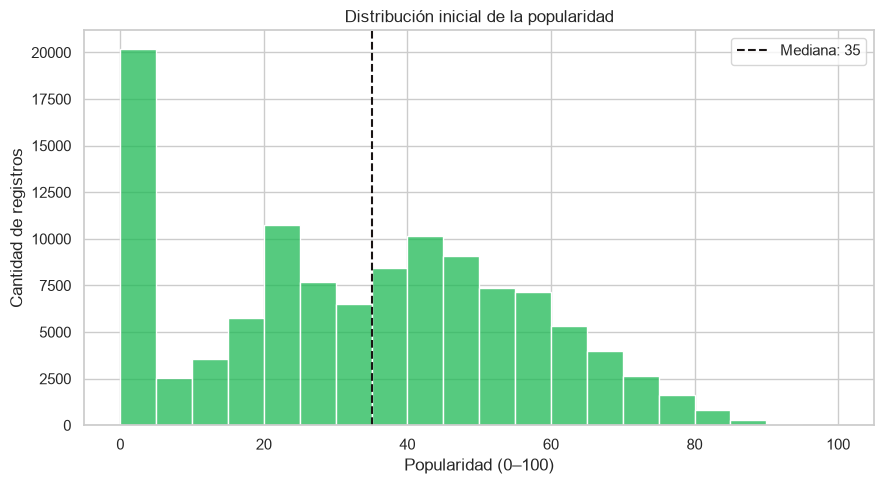

In [11]:
figure = plot_popularity_distribution(tracks)
save_figure(figure, PROJECT_PATHS.figures / "01_popularity_distribution.png")
plt.show()

**Hallazgo:** la media es 33,24 y la mediana 35. El 14,05% de las filas posee popularidad cero, mientras que solo el 4,8% alcanza 70 o más. El umbral 70 es operativo y no una categoría oficial de Spotify. La concentración en valores bajos y medios anticipa que una futura clasificación podría quedar desbalanceada.

### 8.2 Duración

La duración se convierte vectorialmente a minutos con NumPy. La figura limita la vista al percentil 99 para que registros extremadamente largos no oculten la distribución principal; los valores no se eliminan del dataset.

In [12]:
duration_minutes.describe(percentiles=[0.95, 0.99]).to_frame().T

,count,mean,std,min,50%,95%,99%,max
duration_minutes,114000.0,3.800486,1.788295,0.0,3.548433,6.452785,8.848461,87.28825


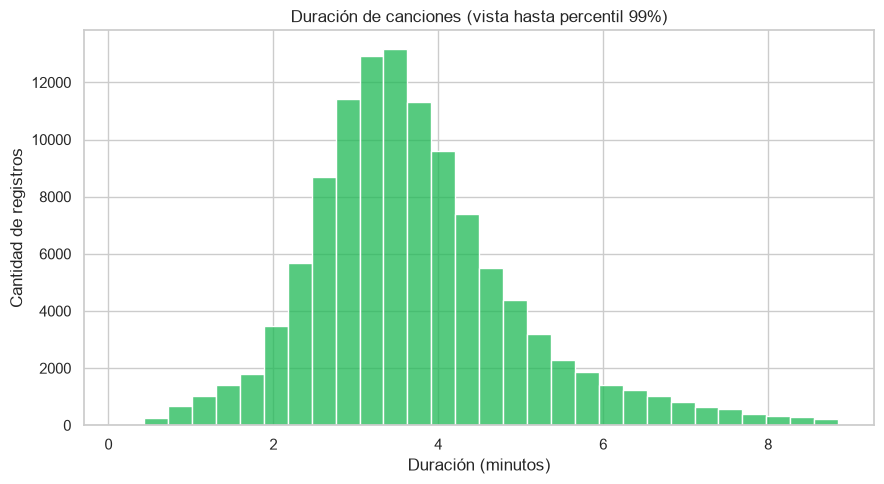

In [13]:
figure = plot_duration_distribution(tracks, upper_quantile=0.99)
save_figure(figure, PROJECT_PATHS.figures / "02_duration_distribution.png")
plt.show()

**Hallazgo:** la mediana es 3,55 minutos y el percentil 99 es 8,85 minutos, pero el máximo llega a 87,29 minutos. También existe una duración igual a cero. Estos casos requieren revisión posterior; no deben descartarse solo por ser extremos.

### 8.3 Contenido explícito

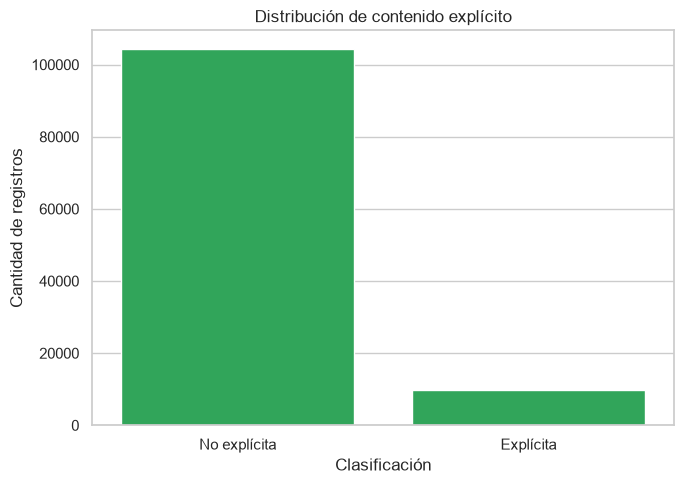

In [14]:
figure = plot_explicit_distribution(tracks)
save_figure(figure, PROJECT_PATHS.figures / "03_explicit_distribution.png")
plt.show()

**Hallazgo:** el 8,55% de los registros se marca como explícito. La documentación de Spotify indica que `False` puede representar contenido no explícito o estado desconocido, por lo que debe evitarse una interpretación absoluta.

### 8.4 Características acústicas en escala 0–1

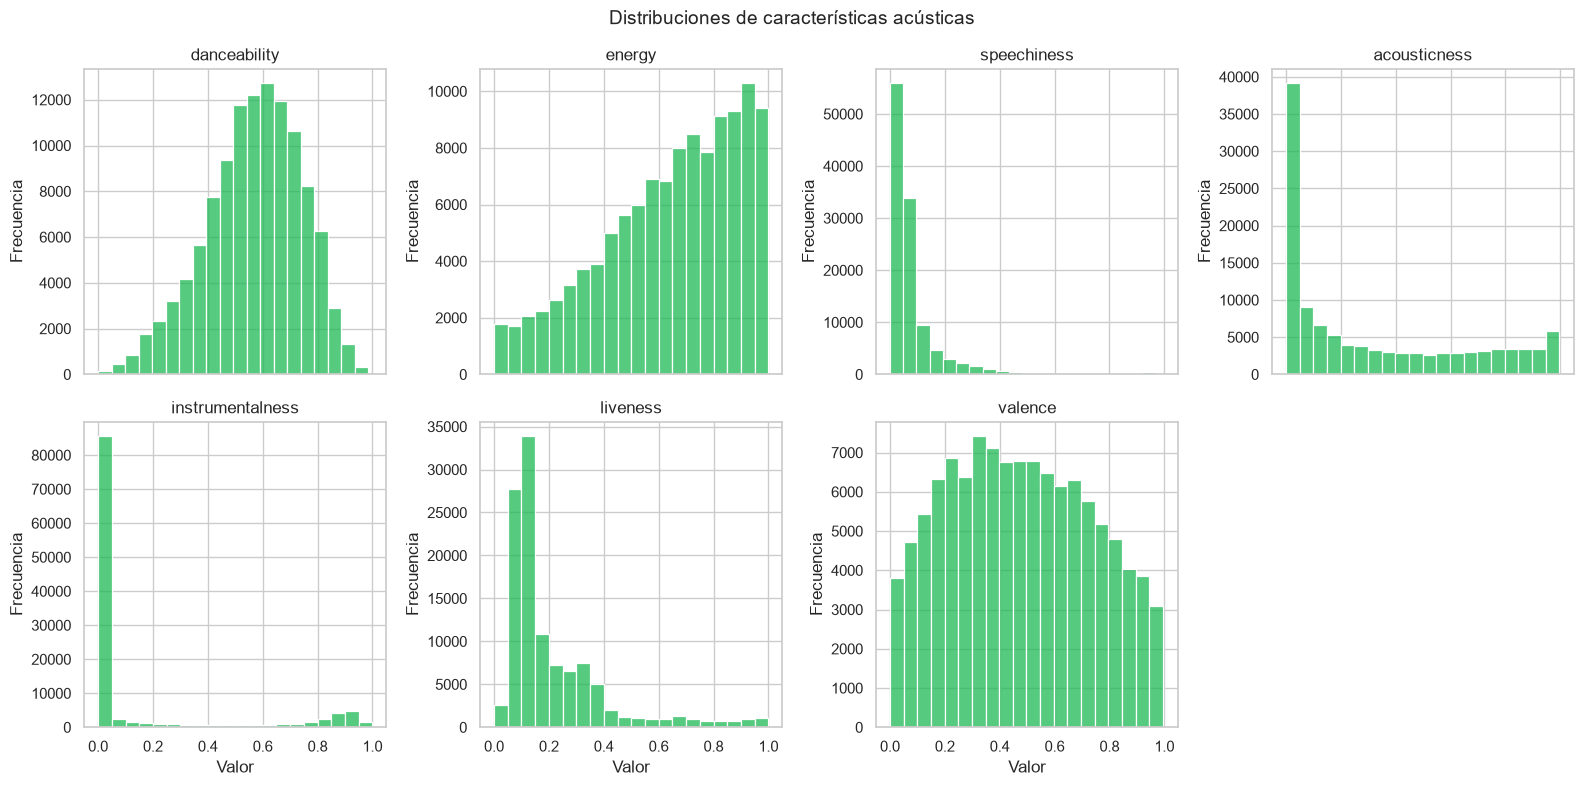

In [15]:
audio_features = (
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
)
figure = plot_audio_feature_distributions(tracks, audio_features)
save_figure(figure, PROJECT_PATHS.figures / "04_audio_feature_distributions.png")
plt.show()

**Hallazgo:** `speechiness`, `instrumentalness` y `liveness` presentan fuerte concentración cerca de cero. En cambio, `danceability`, `energy` y `valence` se distribuyen de forma más amplia. Esto afecta el tipo de resumen y transformación que podría considerarse posteriormente.

### 8.5 Cobertura de géneros

In [16]:
genre_counts = tracks["track_genre"].value_counts()
genre_counts.describe().to_frame(name="registros_por_genero")

,registros_por_genero
count,114.0
mean,1000.0
std,0.0
min,1000.0
25%,1000.0
50%,1000.0
75%,1000.0
max,1000.0


**Hallazgo:** los 114 géneros contienen exactamente 1.000 filas cada uno. Esta regularidad sugiere un diseño de muestreo balanceado; es útil para comparar géneros, pero no permite inferir su prevalencia real en Spotify.

## 9. Entrega documentada al Integrante 2

### Conclusiones de la comprensión y exploración inicial

1. El dataset es amplio y casi completo, pero el bajo número de nulos no implica ausencia de problemas de calidad.
2. La repetición de `track_id` es el principal riesgo estructural: 16.641 IDs se repiten y generan 24.259 apariciones adicionales.
3. `Unnamed: 0` es un índice exportado y deberá eliminarse de la versión preparada.
4. El único registro con nulos también presenta duración y popularidad cero; requiere una decisión justificada.
5. La popularidad se concentra en valores bajos y medios y solo 4,8% de las filas alcanza 70 puntos.
6. La cobertura de géneros está perfectamente balanceada, por lo que no representa su frecuencia natural.
7. La popularidad depende de factores no presentes —promoción, temporalidad y exposición—, lo que limita cualquier conclusión predictiva basada solo en audio.

### Próxima etapa del equipo

La preparación deberá resolver el índice exportado, el registro anómalo y la estrategia de consolidación por `track_id`. Ninguna de esas decisiones se aplica dentro de este notebook para conservar una separación clara de responsabilidades.